In [ ]:
from pathlib import Path
import pandas as pd

DATA_ROOT = Path("../../data/raw/mvtec_ad")
categories = sorted([d.name for d in DATA_ROOT.iterdir() if d.is_dir() and (d / "test").exists()])
print(categories)


['bottle', 'cable', 'capsule', 'carpet', 'grid', 'hazelnut', 'leather', 'metal_nut', 'pill', 'screw', 'tile', 'toothbrush', 'transistor', 'wood', 'zipper']


In [ ]:
records = []

for category in categories:
    test_dir = DATA_ROOT / category / "test"
    for subfolder in sorted(test_dir.iterdir()):
        if not subfolder.is_dir():
            continue
        n_images = len(list(subfolder.glob("*.png")))
        label = "good" if subfolder.name == "good" else "defective"
        records.append({"category": category, "subfolder": subfolder.name, "label": label, "count": n_images})

df = pd.DataFrame(records)
df.head(60)

,category,subfolder,label,count
0,bottle,broken_large,defective,20
1,bottle,broken_small,defective,22
2,bottle,contamination,defective,21
3,bottle,good,good,20
4,cable,bent_wire,defective,13
5,cable,cable_swap,defective,12
6,cable,combined,defective,11
7,cable,cut_inner_insulation,defective,14
8,cable,cut_outer_insulation,defective,10
9,cable,good,good,58


In [35]:
category_counts = df.groupby(["category", "label"])["count"].sum().unstack(fill_value=0)
category_counts["total"] = category_counts["good"] + category_counts["defective"]
category_counts["defective_ratio"] = category_counts["defective"] / category_counts["total"]
category_counts

label,defective,good,total,defective_ratio
category,,,,
bottle,63,20,83,0.759036
cable,92,58,150,0.613333
capsule,109,23,132,0.825758
carpet,89,28,117,0.760684
grid,57,21,78,0.730769
hazelnut,70,40,110,0.636364
leather,92,32,124,0.741935
metal_nut,93,22,115,0.808696
pill,141,26,167,0.844311


In [36]:
from scipy.stats import chi2_contingency

contingency_table = category_counts[["good", "defective"]]
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2:.3f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p_value:.2e}")

Chi-square statistic: 95.392
Degrees of freedom: 14
p-value: 3.60e-14


In [37]:
import numpy as np
from PIL import Image

sample_mask_path = DATA_ROOT / "bottle" / "ground_truth" / "broken_large" / "000_mask.png"
mask = np.array(Image.open(sample_mask_path))

print("Shape:", mask.shape)
print("Unique values:", np.unique(mask))
print("Anomalous pixels:", (mask > 0).sum())
print("Total pixels:", mask.size)

Shape: (900, 900)
Unique values: [  0 255]
Anomalous pixels: 88192
Total pixels: 810000


In [38]:
pixel_records = []

for category in categories:
    gt_dir = DATA_ROOT / category / "ground_truth"
    if not gt_dir.exists():
        continue
    for defect_type_dir in sorted(gt_dir.iterdir()):
        if not defect_type_dir.is_dir():
            continue
        for mask_path in sorted(defect_type_dir.glob("*_mask.png")):
            mask = np.array(Image.open(mask_path))
            anomalous = int((mask > 0).sum())
            normal = int(mask.size - anomalous)
            pixel_records.append({
                "category": category,
                "defect_type": defect_type_dir.name,
                "anomalous_pixels": anomalous,
                "normal_pixels": normal
            })

pixel_df = pd.DataFrame(pixel_records)
pixel_df.head(20)

,category,defect_type,anomalous_pixels,normal_pixels
0,bottle,broken_large,88192,721808
1,bottle,broken_large,76641,733359
2,bottle,broken_large,125835,684165
3,bottle,broken_large,222091,587909
4,bottle,broken_large,33132,776868
5,bottle,broken_large,33201,776799
6,bottle,broken_large,123810,686190
7,bottle,broken_large,130952,679048
8,bottle,broken_large,105614,704386
9,bottle,broken_large,70875,739125


In [39]:
category_pixel_totals = pixel_df.groupby("category")[["anomalous_pixels", "normal_pixels"]].sum()
category_pixel_totals["total_pixels"] = category_pixel_totals["anomalous_pixels"] + category_pixel_totals["normal_pixels"]
category_pixel_totals["anomalous_ratio"] = category_pixel_totals["anomalous_pixels"] / category_pixel_totals["total_pixels"]
category_pixel_totals.sort_values("anomalous_ratio")

,anomalous_pixels,normal_pixels,total_pixels,anomalous_ratio
category,,,,
screw,418611,124361933,124780544,0.003355
leather,843352,95625640,96468992,0.008742
grid,564944,59203888,59768832,0.009452
capsule,1208676,107791324,109000000,0.011089
carpet,1965794,91357470,93323264,0.021064
toothbrush,673493,30783787,31457280,0.021410
zipper,3274311,121506233,124780544,0.026241
hazelnut,2462314,70938006,73400320,0.033546
pill,3589160,86650840,90240000,0.039773


Chi-Square test cell on the pixel-level table:

In [40]:
pixel_contingency_table = category_pixel_totals[["anomalous_pixels", "normal_pixels"]]
chi2_px, p_value_px, dof_px, expected_px = chi2_contingency(pixel_contingency_table)

print(f"Chi-square statistic: {chi2_px:.3f}")
print(f"Degrees of freedom: {dof_px}")
print(f"p-value: {p_value_px:.2e}")

Chi-square statistic: 41675265.648
Degrees of freedom: 14
p-value: 0.00e+00


In [41]:
pixel_df["anomalous_ratio"] = pixel_df["anomalous_pixels"] / (pixel_df["anomalous_pixels"] + pixel_df["normal_pixels"])
pixel_df[["category", "defect_type", "anomalous_ratio"]].head(20)

,category,defect_type,anomalous_ratio
0,bottle,broken_large,0.108879
1,bottle,broken_large,0.094619
2,bottle,broken_large,0.155352
3,bottle,broken_large,0.274186
4,bottle,broken_large,0.040904
5,bottle,broken_large,0.040989
6,bottle,broken_large,0.152852
7,bottle,broken_large,0.161669
8,bottle,broken_large,0.130388
9,bottle,broken_large,0.087500


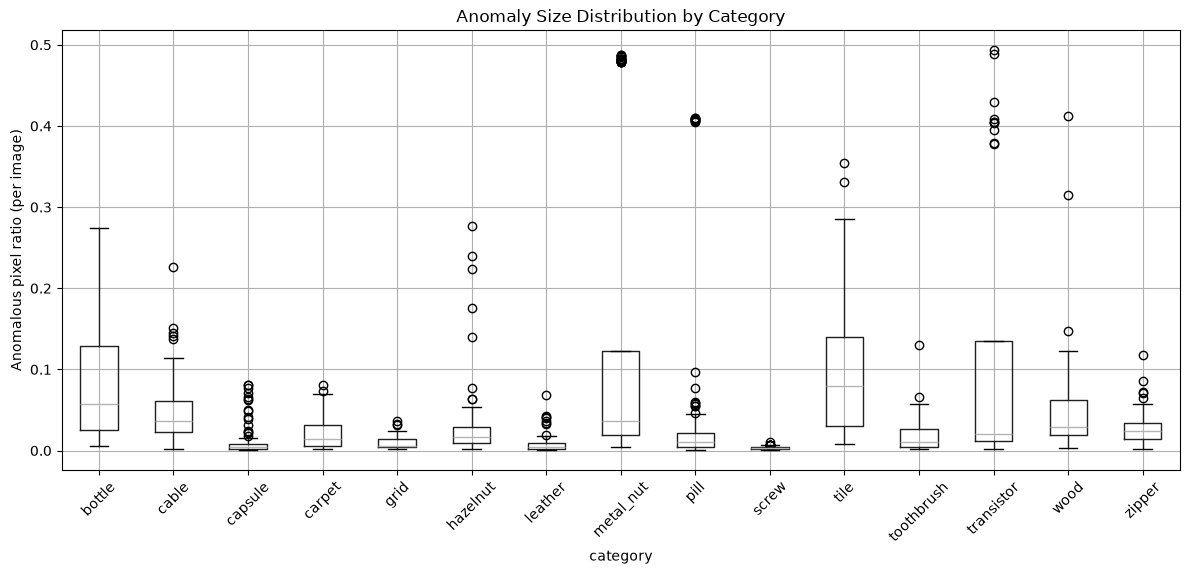

In [42]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))
pixel_df.boxplot(column="anomalous_ratio", by="category", ax=ax, rot=45)
ax.set_ylabel("Anomalous pixel ratio (per image)")
ax.set_title("Anomaly Size Distribution by Category")
plt.suptitle("")
plt.tight_layout()
plt.show()

In [43]:
from scipy.stats import kruskal

groups = [group["anomalous_ratio"].values for name, group in pixel_df.groupby("category")]
h_stat, p_value_kw = kruskal(*groups)

print(f"H-statistic: {h_stat:.3f}")
print(f"p-value: {p_value_kw:.2e}")

H-statistic: 626.507
p-value: 1.21e-124
